# Compute $\langle r^2\rangle(L)$ at $\phi=0$ using EC back-rotation with stats

System: $V(r) = 2.0\exp\left[-\left(\frac{r-3}{1.5}\right)^2\right]$, supports $s$-wave resonance at $E=1.606-i0.047$. This notebook
computes the EC backrotated resonance at multiple values of the system length $L$, and plots $E_\text{back-rotated}(L)$
and $(r^2)_\text{back-rotated}(L)$.

In [10]:
from src.ecensemble import ECEnsemble
from src.ec import ECSystem, TakagiRegularization
from src.dvr import DVR

import numpy as np
from numpy import pi, exp
import random
import matplotlib.pyplot as plt

import logging
logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.WARNING, format="[%(levelname)s] %(name)s: %(message)s")
logging.getLogger("matplotlib").setLevel(logging.WARNING)

In [ ]:
save_plots = True
plots_folder = Path("./plots/ec_backrotated_radius_wstats_wrtL")
plots_folder.mkdir(exist_ok=True, parents=True)

In [11]:
# define system parameters
n = 256                      # number of DVR grid points
n_ecsystems = 128              # number of EC computations per phi
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance

def gauss_s(r):
    return 2.0 * exp(-((r-3.0)/1.5)**2) # potential

### Compute exact $\langle r_\theta^2 \rangle (L)$

In [12]:
# compute exact <r^2>(L)
exact_Ls = np.linspace(20.0, 50.0, 150)
exact_rrs = []
exact_energies = []

for L in exact_Ls:
    dvr_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    energy, eigstate = dvr_system.closest_to_resonance(real_res)
    rr = dvr_system.compute_rr(eigstate[:, 0], rotate_rr=True)
    exact_energies.append(energy)
    exact_rrs.append(rr)

### Compute EC-predicted $\langle r_{\theta\rightarrow0}^2 \rangle (L)$

In [13]:
predict_Ls = np.linspace(20.0, 50.0, 20)
phi_training_range, num_phi_points = [pi/24, pi/6], 50
phi_predict = 0.0
predict_energies_stats, predict_rrs_stats = [], []

for L in predict_Ls:
    logger.info(rf"Running EC systems at L = {L}.")
    # for each L in, construct EC ensemble and train all ECs
    dvr_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    EC_ensemble = ECEnsemble(n_ecsystems, dvr_system, real_res, regularizer=None)
    EC_ensemble.train(phi_training_range, num_phi_points)
    EC_ensemble.construct_bases()

    # predict energies and rrs at phi=0
    energy_stats, rrs_stats = EC_ensemble.predict_energies_rrs_wstats(phi_predict, rotate_rr=True)
    predict_energies_stats.append(energy_stats)
    predict_rrs_stats.append(rrs_stats)

In [16]:
# plot results with error bands
# decompose results
def decompose_stats(data):
    # decompose stats into median, err68, err95 for each L
    # median has shape (len(Ls)), err68 / err95 have shape (len(Ls), 2)
    median = np.array([datai[0] for datai in data])
    err68 = np.array([datai[1] for datai in data])
    err95 = np.array([datai[2] for datai in data])
    return median, err68, err95

def plot_data(fig, axs, predict_Ls, predict_data, cutoff: int):
    ax1, ax2 = axs
    median, err68, err95 = decompose_stats(predict_data)

    # apply cutoffs
    median = median[cutoff:]
    err68, err95 = err68[cutoff:, :], err95[cutoff:, :]
    predict_Ls = predict_Ls[cutoff:]

    ax1.scatter(predict_Ls, np.real(median), marker='x', c='red', label="Predict (median)")
    ax2.scatter(predict_Ls, np.imag(median), c='red', marker='x', label="Predict (median)")
    ax1.errorbar(predict_Ls, np.real(median),
                yerr=(np.real(err68[:, 0]), np.real(err68[:, 1])),
                fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
    ax1.errorbar(predict_Ls, np.real(median),
                yerr=(np.real(err95[:,0]), np.real(err95[:,1])),
                fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
    ax2.errorbar(predict_Ls, np.imag(median),
                yerr=(np.imag(err68[:,0]), np.imag(err68[:,1])),
                fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
    ax2.errorbar(predict_Ls, np.imag(median),
                yerr=(np.imag(err95[:,0]), np.imag(err95[:,1])),
                fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
    ax1.legend(loc=(0.01,0.45))
    ax2.legend(loc=(0.01,0.45))
    ax2.set_xlabel(r"$L$")

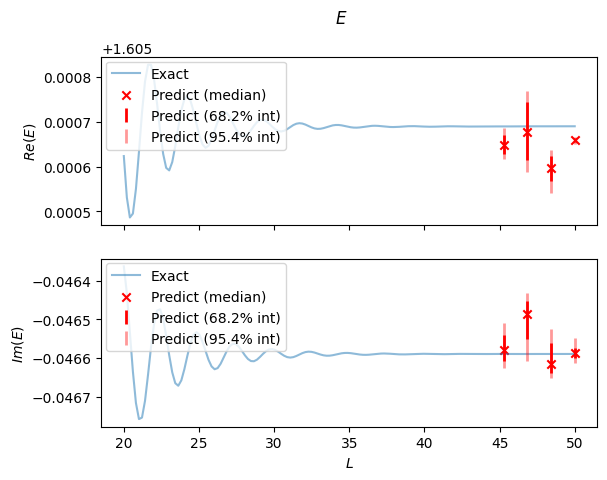

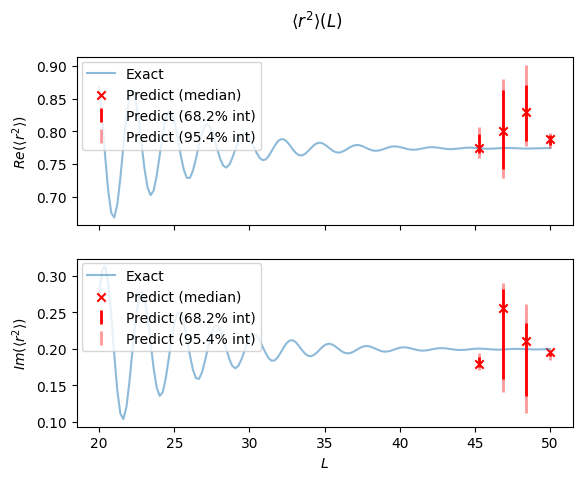

In [18]:
# energy plot
cutoff = -4
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(exact_Ls, np.real(exact_energies), alpha=0.5, label="Exact")
ax2.plot(exact_Ls, np.imag(exact_energies), alpha=0.5, label="Exact")
plot_data(fig, (ax1, ax2), predict_Ls, predict_energies_stats, cutoff=cutoff)
ax2.set_ylabel(r"$Im(E)$")
ax1.set_ylabel(r"$Re(E)$")
fig.suptitle(r"$E$")
if save_plots:
    plt.savefig(plots_folder / "ec_backrot_energy__phitrain_{phi_training_range[0]:.3f}_{phi_training_range[1]:.3f}_{num_phi_points}__phipredict_{phi_predict:.3f}.png")
plt.show()

# rr plot
cutoff = -4
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(exact_Ls, np.real(exact_rrs), alpha=0.5, label="Exact")
ax2.plot(exact_Ls, np.imag(exact_rrs), alpha=0.5, label="Exact")
plot_data(fig, (ax1, ax2), predict_Ls, predict_rrs_stats, cutoff=cutoff)
ax2.set_ylabel(r"$Im(\langle r^2 \rangle)$")
ax1.set_ylabel(r"$Re(\langle r^2 \rangle)$")
fig.suptitle(r"$\langle r^2\rangle(L)$")
if save_plots:
    plt.savefig(plots_folder / "ec_backrot_energy__phitrain_{phi_training_range[0]:.3f}_{phi_training_range[1]:.3f}_{num_phi_points}__phipredict_{phi_predict:.3f}.png")
plt.show()

### Test to see if predictions get better without random sampling

In [7]:
phi_train = np.linspace(pi/24, pi/6, 50)
phi_predict = 0.0
predict_Ls = np.linspace(35.0, 50.0, 20)
predict_rrs = []
for L in predict_Ls:
    dvr_system = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    EC_system = ECSystem(dvr_system, real_res)
    EC_system.train(phi_train)
    EC_system.construct_basis()
    _, rrs = EC_system.predict_energies_rrs([phi_predict], rotate_rr=False)
    predict_rrs.append(rrs[0])
predict_rrs = np.array(predict_rrs)

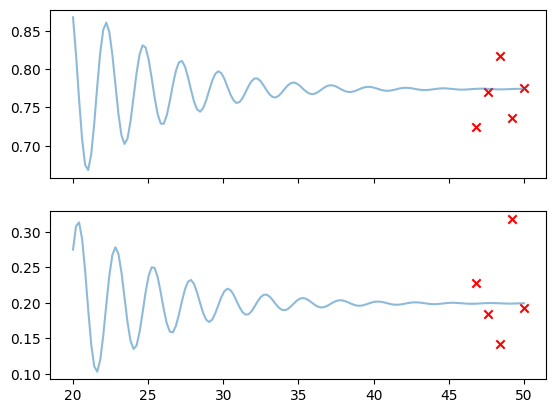

In [8]:
cutoff=-5
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(exact_Ls, np.real(exact_rrs), alpha=0.5, label="Exact")
ax2.plot(exact_Ls, np.imag(exact_rrs), alpha=0.5, label="Exact")
ax1.scatter(predict_Ls[cutoff:], np.real(predict_rrs)[cutoff:], marker='x', c='red', label="Predict")
ax2.scatter(predict_Ls[cutoff:], np.imag(predict_rrs)[cutoff:], c='red', marker='x', label="Predict")
plt.show()